In [35]:
import numpy as np
import pandas as pd
import pathlib
import pickle as pkl
import sys
import os
from icecream import ic

In [36]:
sys.path.append(os.path.abspath("../"))
from utils import plot_rank_corrs, get_rank_corrs

In [37]:
sys.path.append(os.path.abspath("../../"))
from paths import resources_path

scores_path = resources_path / pathlib.Path("scores/layer_exp/scores.pkl")
# full_df_path = resources_path / pathlib.Path("full_dfs/layer_exp/full_df.csv")
full_df_path = resources_path / pathlib.Path("results/layer_exp/fast_last_layers_run/full_df_self_computed.csv")
# full_df_path = resources_path / pathlib.Path("full_dfs/layer_exp/full_df_self_computed.csv")

# Load `full_df`

In [38]:
full_df = pd.read_csv(full_df_path)

# Dataframe subsetting

In [39]:
def best_probing_seed(task, ref_depth, list_ref_seeds):
    data_dict = pkl.load(open(scores_path, "rb"))
    list_to_max = [
        np.mean(data_dict[task][seed][ref_depth + 1][0][0]) for seed in list_ref_seeds
    ]
    idx, _ = max(enumerate(list_to_max), key=lambda x: x[1])
    return list_ref_seeds[idx]


def layer_sub_df(df, ref_depth, ref_seed):
    sub_df = df.loc[
        ((df["seed1"] == ref_seed) & (df["layer1"] == ref_depth))
        | ((df["seed2"] == ref_seed) & (df["layer2"] == ref_depth))
    ].reset_index()

    # TODO: maybe get rid of this assert
    num_layers = 12
    # assert len(sub_df) == num_layers * 10
    return sub_df

# Rank correlation results

In [40]:
# the function to aggregate rank correlations is a bit different from the other experiments since in this case we sometimes have to aggregate both over depths and over seeds
def aggregate_rank_corrs(df, task, layer_depths, list_ref_seeds, METRICS, sub_df_fn):
    rho = {metric: [] for metric in METRICS}
    rho_p = {metric: [] for metric in METRICS}
    tau = {metric: [] for metric in METRICS}
    tau_p = {metric: [] for metric in METRICS}
    bad_fracs = {metric: [] for metric in METRICS}
    
    for ref_depth in layer_depths:
        ref_seed = best_probing_seed(task, ref_depth, list_ref_seeds)
        sub_df = sub_df_fn(df, ref_depth, ref_seed)
        for metric in METRICS:
            rho_corr, rho_os_p, tau_corr, tau_os_p, bad_frac = get_rank_corrs(sub_df, metric, task) 
            
            rho[metric].append(rho_corr)
            rho_p[metric].append(rho_os_p)
            tau[metric].append(tau_corr)
            tau_p[metric].append(tau_os_p)
            bad_fracs[metric].append(bad_frac)
    return rho, rho_p, tau, tau_p, bad_fracs

In [41]:
task = 'QNLI'
layer_depths = [11]
list_ref_seeds = list(range(1, 11))
# METRICS = ["Procrustes", "CKA", "PWCCA"]
METRICS = ["rbf_rwka_auc", "rbf_rwka", "softmax_rwka", "softmax_rwka_auc", "PWCCA", "CKA", "Procrustes", "cka_rbf", "cka_rbf_auc", "mutual_knn", "mutual_knn_auc", "cknna", "cknna_auc"]

In [42]:
rho, rho_p, tau, tau_p, bad_fracs = aggregate_rank_corrs(full_df, task, layer_depths, list_ref_seeds, METRICS, layer_sub_df)

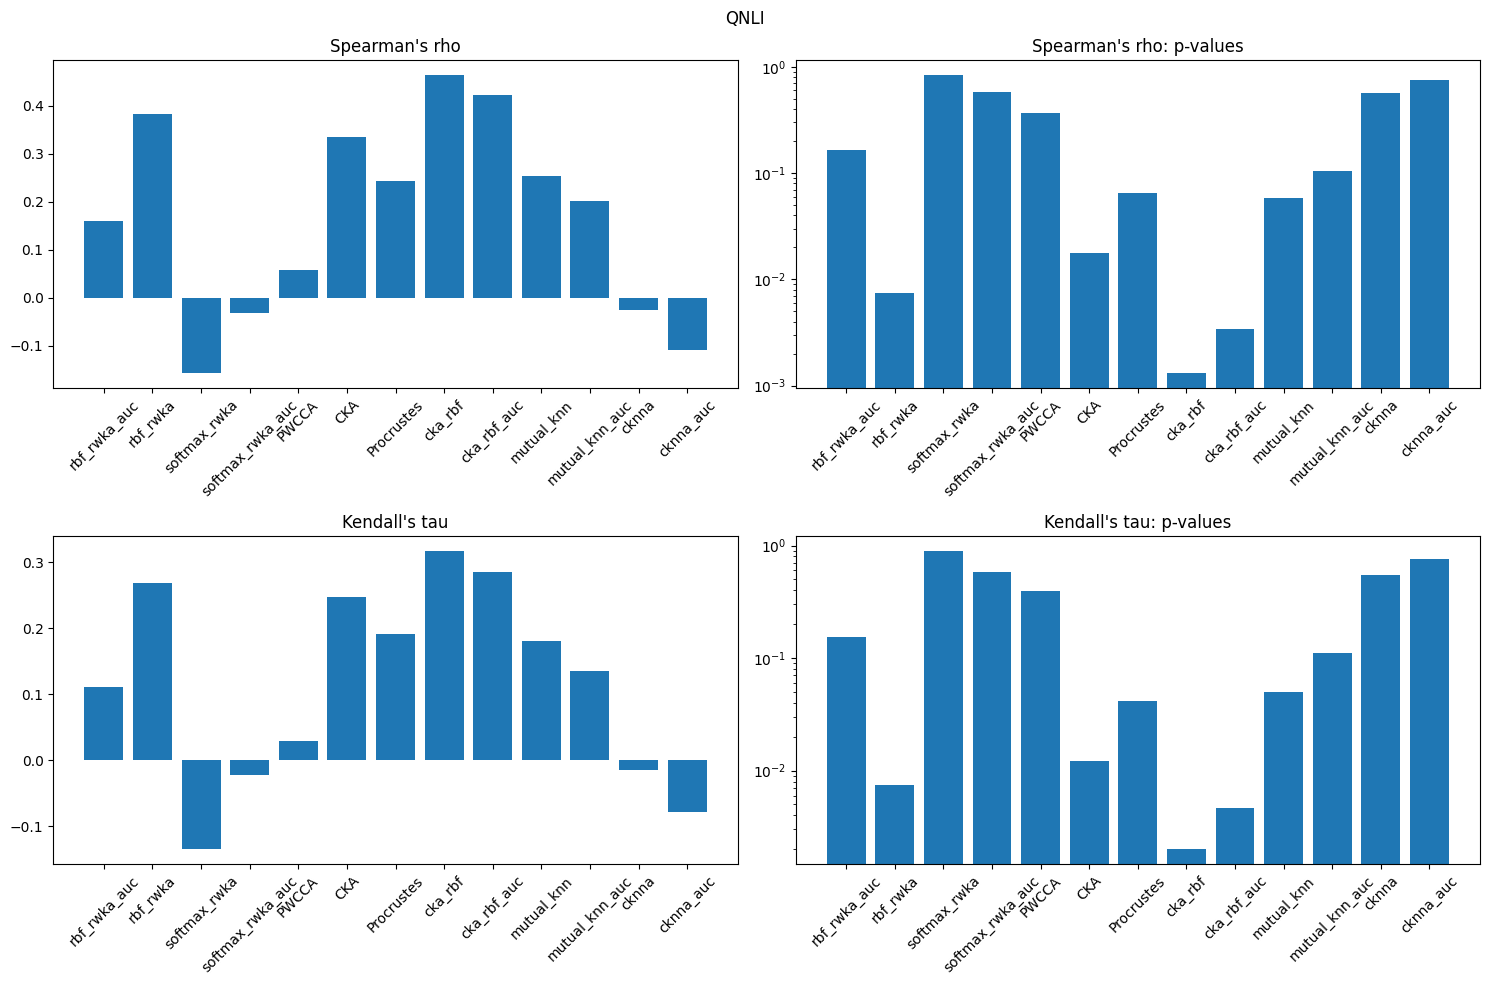

In [43]:
plot_rank_corrs(rho, rho_p, tau, tau_p, METRICS, title = task)

In [44]:
avg_rho = {metric: round(np.mean(rho[metric]), 3) for metric in METRICS}
avg_rho_p = {metric: round(np.mean(rho_p[metric]), 3) for metric in METRICS}
avg_tau = {metric: round(np.mean(tau[metric]), 3) for metric in METRICS}
avg_tau_p = {metric: round(np.mean(tau_p[metric]), 3) for metric in METRICS}

for metric in METRICS:
    ic("\n")
    ic(metric)
    ic(avg_rho[metric])
    ic(avg_rho_p[metric])
    ic(avg_tau[metric])
    ic(avg_tau_p[metric])

ic| "\n": '
           '
ic| metric: 'rbf_rwka_auc'
ic| avg_rho[metric]: 0.158
ic| avg_rho_p[metric]: 0.164
ic| avg_tau[metric]: 0.112
ic| avg_tau_p[metric]: 0.155
ic| "\n": '
           '
ic| metric: 'rbf_rwka'
ic| avg_rho[metric]: 0.382
ic| avg_rho_p[metric]: 0.007
ic| avg_tau[metric]: 0.268
ic| avg_tau_p[metric]: 0.007
ic| "\n": '
           '
ic| metric: 'softmax_rwka'
ic| avg_rho[metric]: -0.158
ic| avg_rho_p[metric]: 0.835
ic| avg_tau[metric]: -0.135
ic| avg_tau_p[metric]: 0.889
ic| "\n": '
           '
ic| metric: 'softmax_rwka_auc'
ic| avg_rho[metric]: -0.032
ic| avg_rho_p[metric]: 0.577
ic| avg_tau[metric]: -0.022
ic| avg_tau_p[metric]: 0.579
ic| "\n": '
           '
ic| metric: 'PWCCA'
ic| avg_rho[metric]: 0.056
ic| avg_rho_p[metric]: 0.365
ic| avg_tau[metric]: 0.03
ic| avg_tau_p[metric]: 0.394
ic| "\n": '
           '
ic| metric: 'CKA'
ic| avg_rho[metric]: 0.334
ic| avg_rho_p[metric]: 0.018
ic| avg_tau[metric]: 0.248
ic| avg_tau_p[metric]: 0.012
ic| "\n": '
           '
ic| 

## Correlation with absolute layer difference
Compute correlations between each similarity metric and $|layer1-layer2|$, split by seed relation: same seed, different seed, and all pairs.

In [45]:
from scipy.stats import spearmanr, kendalltau


def metric_vs_layer_gap_corr(df, metrics, seed_mode="all"):
    if seed_mode == "same":
        sub_df = df[df["seed1"] == df["seed2"]].copy()
    elif seed_mode == "different":
        sub_df = df[df["seed1"] != df["seed2"]].copy()
    elif seed_mode == "all":
        sub_df = df.copy()
    else:
        raise ValueError(f"Unknown seed_mode: {seed_mode}")

    sub_df["abs_layer_diff"] = (sub_df["layer1"] - sub_df["layer2"]).abs()

    gap_rho = {metric: [] for metric in metrics}
    gap_rho_p = {metric: [] for metric in metrics}
    gap_tau = {metric: [] for metric in metrics}
    gap_tau_p = {metric: [] for metric in metrics}

    for metric in metrics:
        if metric not in sub_df.columns:
            print(f"Metric {metric} not found in dataframe columns. Skipping.")
            continue

        x = sub_df[metric]
        y = sub_df["abs_layer_diff"]

        rho = spearmanr(x, y)
        tau = kendalltau(x, y)

        if np.isnan(rho.correlation) or np.isnan(tau.correlation):
            continue

        rho_corr = float(rho.correlation)
        tau_corr = float(tau.correlation)

        rho_os_p = (rho.pvalue / 2) if rho_corr > 0 else (1 - rho.pvalue / 2)
        tau_os_p = (tau.pvalue / 2) if tau_corr > 0 else (1 - tau.pvalue / 2)

        gap_rho[metric].append(rho_corr)
        gap_rho_p[metric].append(float(rho_os_p))
        gap_tau[metric].append(tau_corr)
        gap_tau_p[metric].append(float(tau_os_p))

    rows = []
    for metric in metrics:
        if len(gap_rho[metric]) == 0:
            continue
        rows.append(
            {
                "metric": metric,
                "spearman_rho": round(float(np.mean(gap_rho[metric])), 3),
                "spearman_p": format(float(np.mean(gap_rho_p[metric])), ".1e"),
                "kendall_tau": round(float(np.mean(gap_tau[metric])), 3),
                "kendall_p": format(float(np.mean(gap_tau_p[metric])), ".1e"),
            }
        )

    if len(rows) == 0:
        summary_df = pd.DataFrame(columns=["metric", "spearman_rho", "spearman_p", "kendall_tau", "kendall_p"])
    else:
        summary_df = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False)

    metrics_present = [m for m in metrics if len(gap_rho[m]) > 0]

    return summary_df, gap_rho, gap_rho_p, gap_tau, gap_tau_p, metrics_present


Correlation with |layer1-layer2| (seed_mode=same):
          metric  spearman_rho spearman_p  kendall_tau kendall_p
             CKA         0.981    1.8e-71        0.916   2.7e-30
      mutual_knn         0.981    1.8e-71        0.916   2.7e-30
  mutual_knn_auc         0.981    1.8e-71        0.916   2.7e-30
           PWCCA         0.949    4.0e-51        0.841   1.8e-28
      Procrustes         0.949    3.0e-51        0.846   1.7e-28
         cka_rbf         0.949    4.0e-51        0.841   1.8e-28
     cka_rbf_auc         0.949    4.0e-51        0.841   1.8e-28
       cknna_auc         0.918    1.8e-41        0.788   3.1e-25
           cknna         0.912    4.1e-40        0.778   1.1e-24
    rbf_rwka_auc         0.873    1.2e-32        0.725   1.2e-21
softmax_rwka_auc         0.851    2.0e-29        0.695   4.8e-20
        rbf_rwka         0.835    1.7e-27        0.676   4.7e-19
    softmax_rwka         0.820    8.7e-26        0.652   7.1e-18


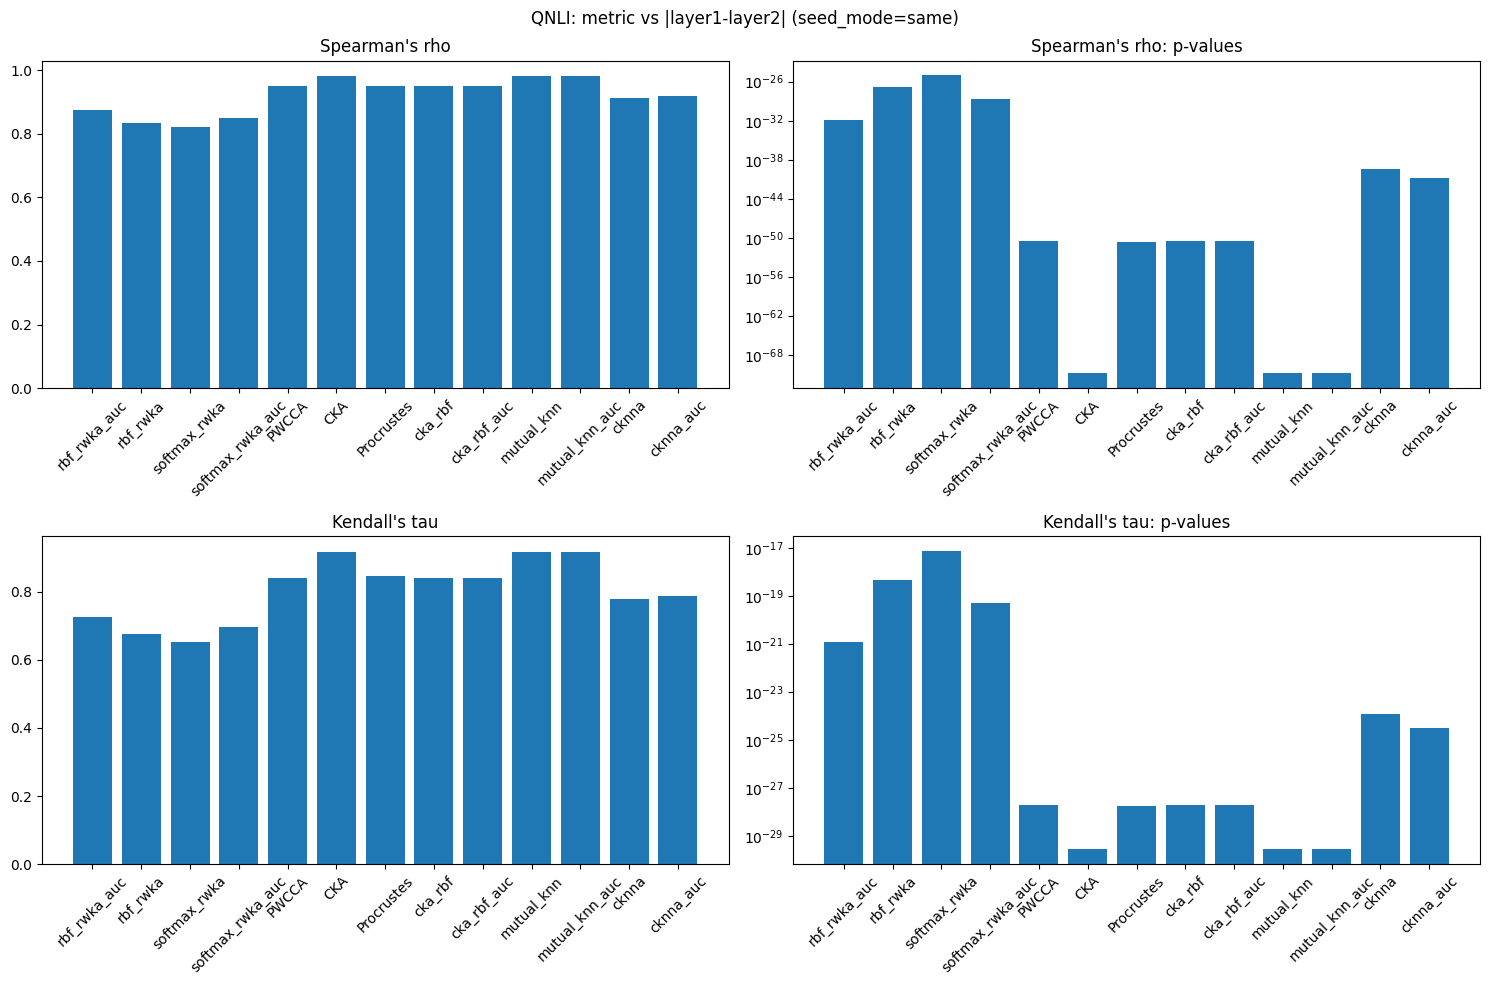


Correlation with |layer1-layer2| (seed_mode=different):
          metric  spearman_rho spearman_p  kendall_tau kendall_p
             CKA         0.666    8.3e-94        0.532   1.7e-80
      Procrustes         0.612    2.0e-75        0.494   1.5e-69
           PWCCA         0.477    2.1e-42        0.381   2.2e-42
         cka_rbf         0.185    3.0e-07        0.147   7.7e-08
     cka_rbf_auc         0.173    1.6e-06        0.136   6.0e-07
    softmax_rwka         0.030    2.1e-01        0.023   2.0e-01
      mutual_knn         0.020    3.0e-01        0.014   3.0e-01
  mutual_knn_auc         0.009    4.1e-01        0.007   4.1e-01
           cknna        -0.012    6.3e-01       -0.009   6.3e-01
softmax_rwka_auc        -0.033    8.1e-01       -0.026   8.2e-01
       cknna_auc        -0.054    9.3e-01       -0.041   9.3e-01
        rbf_rwka        -0.135    1.0e+00       -0.108   1.0e+00
    rbf_rwka_auc        -0.246    1.0e+00       -0.197   1.0e+00


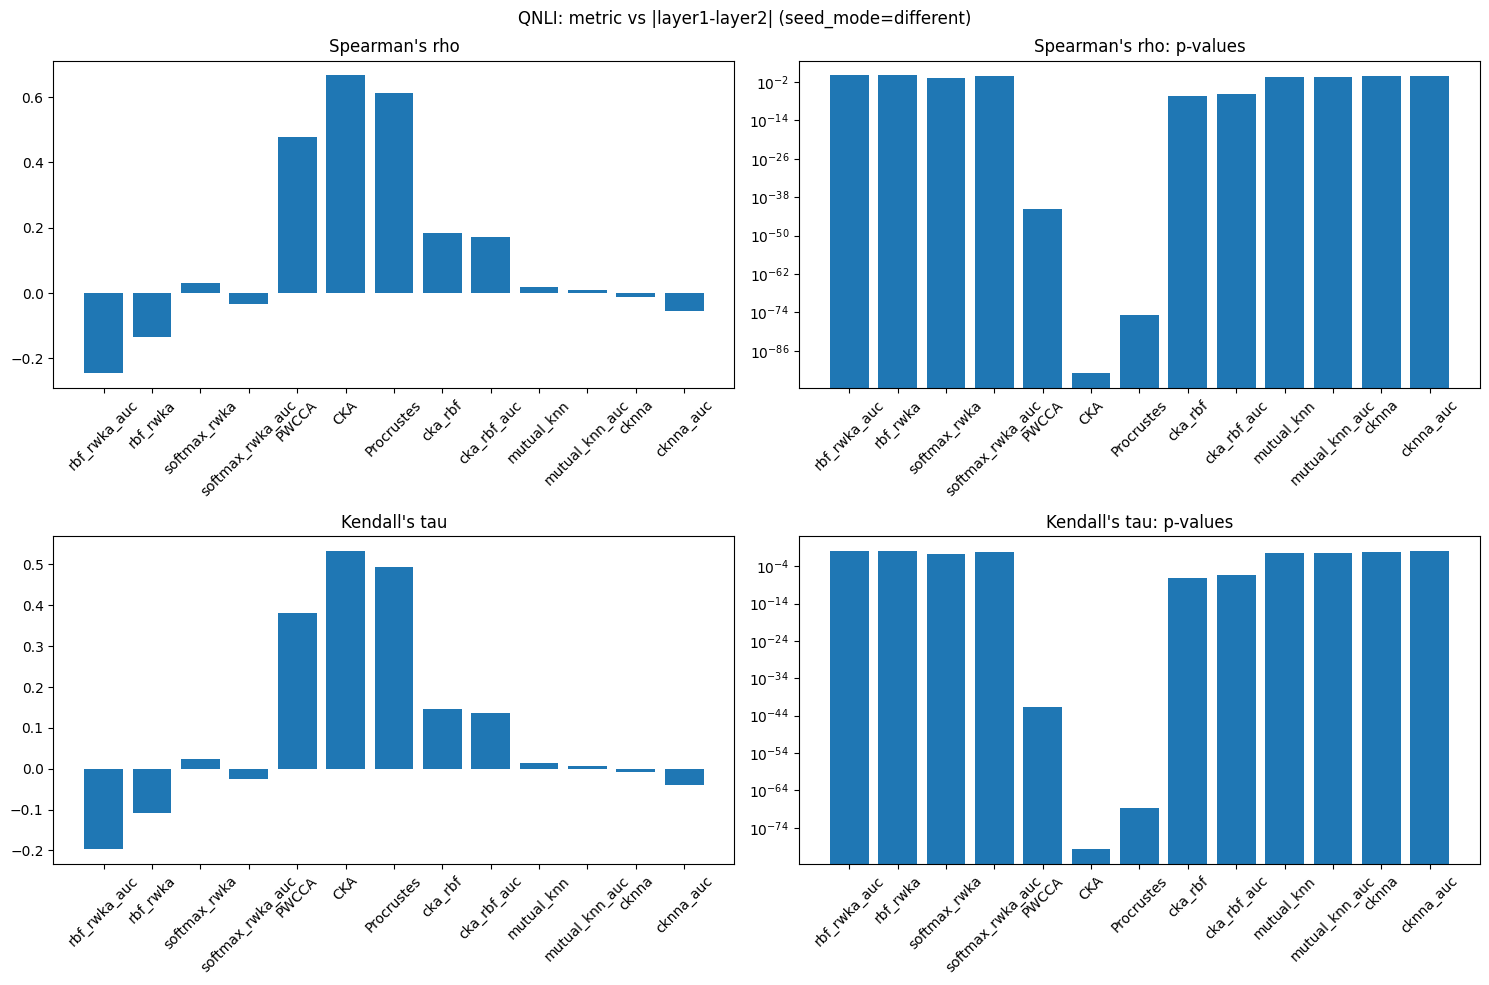


Correlation with |layer1-layer2| (seed_mode=all):
          metric  spearman_rho spearman_p  kendall_tau kendall_p
             CKA         0.603    1.1e-82        0.480   1.4e-74
      Procrustes         0.530    8.2e-61        0.430   1.6e-60
           PWCCA         0.427    6.4e-38        0.344   2.0e-39
         cka_rbf         0.204    2.0e-09        0.164   2.4e-10
     cka_rbf_auc         0.195    9.2e-09        0.155   1.8e-09
    softmax_rwka         0.092    4.3e-03        0.070   3.7e-03
      mutual_knn         0.080    1.1e-02        0.061   9.9e-03
  mutual_knn_auc         0.072    2.0e-02        0.055   1.8e-02
           cknna         0.055    5.7e-02        0.042   5.4e-02
softmax_rwka_auc         0.039    1.3e-01        0.029   1.4e-01
       cknna_auc         0.024    2.5e-01        0.018   2.5e-01
        rbf_rwka        -0.016    6.7e-01       -0.020   7.7e-01
    rbf_rwka_auc        -0.122    1.0e+00       -0.103   1.0e+00


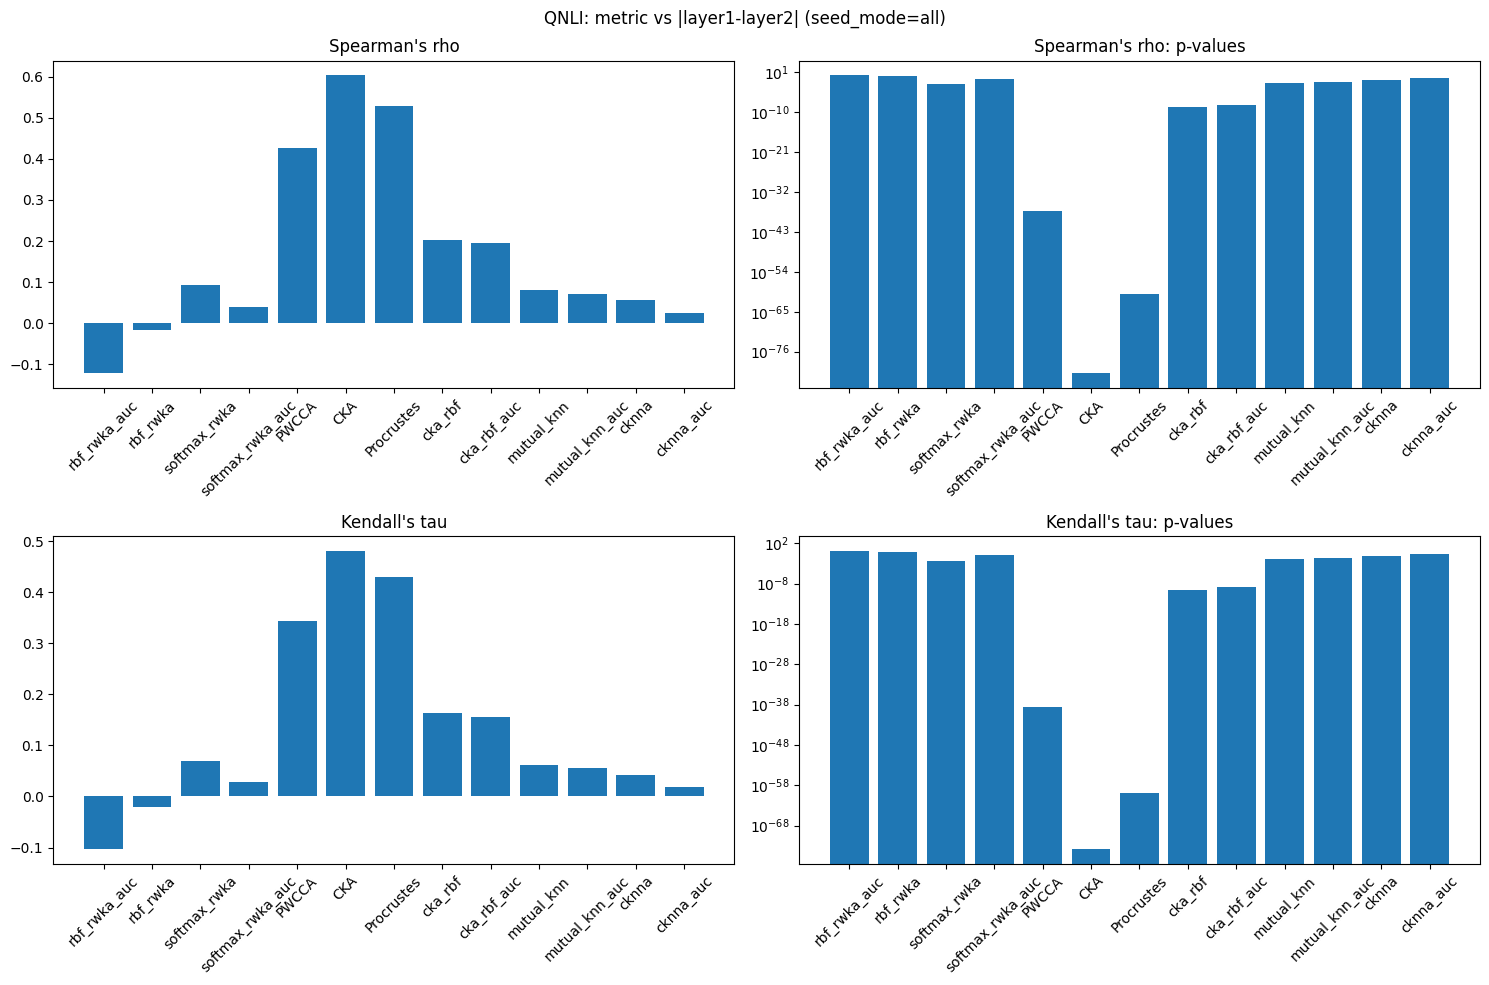

In [46]:
for seed_mode in ["same", "different", "all"]:
    summary_df, gap_rho, gap_rho_p, gap_tau, gap_tau_p, metrics_present = metric_vs_layer_gap_corr(
        full_df, METRICS, seed_mode=seed_mode
    )

    print(f"\nCorrelation with |layer1-layer2| (seed_mode={seed_mode}):")
    if len(summary_df) == 0:
        print("No valid correlations found.")
        continue

    print(summary_df.to_string(index=False))
    plot_rank_corrs(
        gap_rho,
        gap_rho_p,
        gap_tau,
        gap_tau_p,
        metrics_present,
        title=f"{task}: metric vs |layer1-layer2| (seed_mode={seed_mode})",
    )